Unveiling Children's Theory of Mind with rs-fMRI
===

Syuan-Yu Lin (Psychology)

Wei-Hung Lin (Psychology)

National Taiwan University, Taiwan Hub

Keywords:
Theory of Mind, Resting-State fMRI, Machine Learning

## Outline

* Background

* Tools

* Data

* Results

* Future Direction

* Conclusion

* References

# Theory of Mind (ToM)

* Theory of mind refers to the ability to understand people's mental states and use them to predict people's behaviors.

* This ability plays a crucial role in social interactions, communication, and cognitive development.

* Theory of mind enables individuals to infer meaning beyond literal expressions and understand the underlying intentions and beliefs.

# Project Goal

* The previous study showed that the strength of functional connectivity was modulated by the degree of ToM ability (Marchetti et al., 2015).

* We might be able to use children's functional connectivity signature to predict their ToM ability.

* This project aims to predict children's ability of ToM with the rs-fMRI.

# Tools
* Data Visualization (matplotlib)
* Machine learning packages (nilearn, scikit-learn)
* VS Code, Google Colab

# Data

%matplotlib inline

In [ ]:
# Install the needed packages
!pip install nilearn
from nilearn import datasets
from nilearn.input_data import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 34.8 MB/s eta 0:00:00


/tmp/ipykernel_4979/1403437236.py:4: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiLabelsMasker


In [ ]:
# import the behavioral dataset
url = "https://github.com/WeiHungLin/BHS_project/raw/main/participants_childrenonly.csv"
df_behav = pd.read_csv(url)
df_behav

,participant_id,Age,AgeGroup,Child_Adult,Gender,Handedness,ToM Booklet-Matched,ToM Booklet-Matched-NOFB,FB_Composite,FB_Group,WPPSI BD raw,WPPSI BD scaled,KBIT_raw,KBIT_standard,DCCS Summary,Scanlog: Scanner,Scanlog: Coil,Scanlog: Voxel slize,Scanlog: Slice Gap
0,sub-pixar001,4.774812,4yo,child,M,R,0.80,0.736842,6,pass,22.0,13.0,NaN,NaN,3.0,3T1,7-8yo 32ch,3mm iso,0.1
1,sub-pixar002,4.856947,4yo,child,F,R,0.72,0.736842,4,inc,18.0,9.0,NaN,NaN,2.0,3T1,7-8yo 32ch,3mm iso,0.1
2,sub-pixar003,4.153320,4yo,child,F,R,0.44,0.421053,3,inc,15.0,9.0,NaN,NaN,3.0,3T1,7-8yo 32ch,3mm iso,0.1
3,sub-pixar004,4.473648,4yo,child,F,R,0.64,0.736842,2,fail,17.0,10.0,NaN,NaN,3.0,3T1,7-8yo 32ch,3mm iso,0.2
4,sub-pixar005,4.837782,4yo,child,F,R,0.60,0.578947,4,inc,13.0,5.0,NaN,NaN,2.0,3T1,7-8yo 32ch,3mm iso,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,sub-pixar118,10.500000,8-12yo,child,F,R,1.00,1.000000,6,pass,NaN,NaN,37.0,119.0,NaN,3T1,32ch adult,3.13 mm iso,NaN
118,sub-pixar119,8.620000,8-12yo,child,F,R,1.00,1.000000,5,pass,NaN,NaN,33.0,121.0,NaN,3T1,32ch adult,3.13 mm iso,NaN
119,sub-pixar120,11.480000,8-12yo,child,F,R,1.00,1.000000,5,pass,NaN,NaN,38.0,117.0,NaN,3T1,32ch adult,3.13 mm iso,NaN
120,sub-pixar121,8.760000,8-12yo,child,F,R,1.00,1.000000,6,pass,NaN,NaN,37.0,130.0,NaN,3T1,32ch adult,3.13 mm iso,NaN


In [ ]:
participant_df = pd.DataFrame({
    'Number': [122],
    'Age Mean': [6.71],
    'Age Range': ["3 - 12"],
    'ToM Mean': [0.775],
    'ToM Range':["0.24 - 1"]
}, index = [0])


styled_participant_df = participant_df.style.set_properties(**{'background-color': 'lightblue',
                                       'color': 'black',
                                       'font-family': 'Arial',
                                       'text-align': 'center'})

# Participant

In [ ]:
styled_participant_df

,Number,Age Mean,Age Range,ToM Mean,ToM Range
0,122,6.710000,3 - 12,0.775000,0.24 - 1


In [ ]:
# fetch the preprocessed rs-fMRI dataset
data = datasets.fetch_development_fmri()

[fetch_development_fmri] Added README.md to /root/nilearn_data

[fetch_development_fmri] Dataset created in /root/nilearn_data/development_fmri

[fetch_development_fmri] Added README.md to /root/nilearn_data/development_fmri

[fetch_development_fmri] Dataset created in /root/nilearn_data/development_fmri/development_fmri

[fetch_development_fmri] Downloading data from https://osf.io/yr3av/download ...

...

[fetch_development_fmri]  ...done. (2 seconds, 0 min)

[fetch_development_fmri] Downloading data from https://osf.io/download/5cb4700cf2be3c0017056f70/ ...

[fetch_development_fmri]  ...done. (3 seconds, 0 min)

[fetch_development_fmri] Downloading data from https://osf.io/download/5cb46e4fa3bc970019f0713b/ ...

[fetch_development_fmri]  ...done. (2 seconds, 0 min)

In [ ]:
# Check the dataset size
len(data.func)

155

In [ ]:
parcellations = datasets.fetch_atlas_basc_multiscale_2015()
print(parcellations.keys())

[fetch_atlas_basc_multiscale_2015] Dataset found in /root/nilearn_data/basc_multiscale_2015

dict_keys(['maps', 'labels', 'description', 'lut', 'atlas_type', 'template'])


In [ ]:
# Retrieve the atlas for extracting features
parcellations = datasets.fetch_atlas_basc_multiscale_2015(resolution=64)
atlas_filename = parcellations['maps']

masker = NiftiLabelsMasker(labels_img = atlas_filename,
                           standardize = True,
                           memory = 'nilearn_cache',
                           verbose = 0)


correlation_measure = ConnectivityMeasure(kind='correlation',
                      vectorize=True,
                      discard_diagonal=True)

[fetch_atlas_basc_multiscale_2015] Dataset found in /root/nilearn_data/basc_multiscale_2015

In [ ]:
# Create the correlation matrix for all children
all_features = []

for i,sub in enumerate(data.func):
  if i > 32:
    # Extract the timeseries from the ROIs in the atlas
    time_series = masker.fit_transform(sub, confounds = data.confounds[i])
    # Create a correlation matrix
    correlation_matrix = correlation_measure.fit_transform([time_series])[0]
    # Add to the list
    all_features.append(correlation_matrix)
    # Kepp track of the progress
    print('finished %s of %s'%((i+1),len(data.func)))
  else:
    continue


/tmp/ipykernel_4979/81954493.py:7: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(sub, confounds = data.confounds[i])
/tmp/ipykernel_4979/81954493.py:7: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(sub, confounds = data.confounds[i])
/tmp/ipykernel_4979/81954493.py:9: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be r

finished 34 of 155


/tmp/ipykernel_4979/81954493.py:7: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(sub, confounds = data.confounds[i])
/tmp/ipykernel_4979/81954493.py:7: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(sub, confounds = data.confounds[i])
/tmp/ipykernel_4979/81954493.py:9: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be r

finished 35 of 155


/tmp/ipykernel_4979/81954493.py:7: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(sub, confounds = data.confounds[i])
/tmp/ipykernel_4979/81954493.py:7: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(sub, confounds = data.confounds[i])
/tmp/ipykernel_4979/81954493.py:9: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be r

...

/tmp/ipykernel_4979/81954493.py:7: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(sub, confounds = data.confounds[i])
/tmp/ipykernel_4979/81954493.py:7: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(sub, confounds = data.confounds[i])
/tmp/ipykernel_4979/81954493.py:9: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be r

finished 154 of 155


/tmp/ipykernel_4979/81954493.py:7: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(sub, confounds = data.confounds[i])


finished 155 of 155


/tmp/ipykernel_4979/81954493.py:7: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(sub, confounds = data.confounds[i])
/tmp/ipykernel_4979/81954493.py:9: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  correlation_matrix = correlation_measure.fit_transform([time_series])[0]


In [ ]:
# Create the X variables
X_features = np.array(all_features)
X_features.shape

(122, 2016)

Text(0, 0.5, 'subjects')

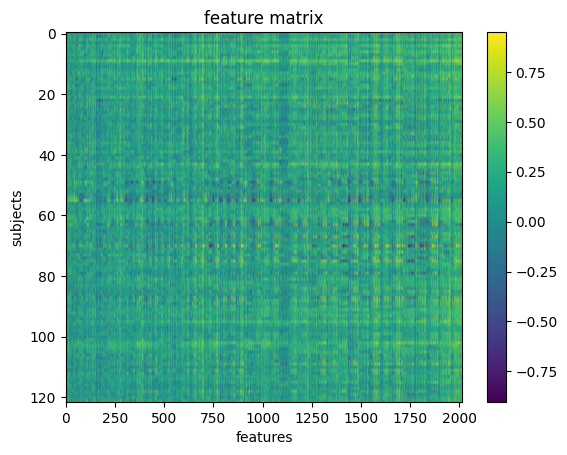

In [ ]:
plt.imshow(X_features, aspect = 'auto')
plt.colorbar()
plt.title('feature matrix')
plt.xlabel('features')
plt.ylabel('subjects')

In [ ]:
# Look over the variable in the behavioral dataframe
df_behav.columns

Index(['participant_id', 'Age', 'AgeGroup', 'Child_Adult', 'Gender',
       'Handedness', 'ToM Booklet-Matched', 'ToM Booklet-Matched-NOFB',
       'FB_Composite', 'FB_Group', 'WPPSI BD raw', 'WPPSI BD scaled',
       'KBIT_raw', 'KBIT_standard', 'DCCS Summary', 'Scanlog: Scanner',
       'Scanlog: Coil', 'Scanlog: Voxel slize', 'Scanlog: Slice Gap'],
      dtype='object')

In [ ]:
# Assign the ToM score as the y variable
y_ToM = df_behav['ToM Booklet-Matched']

<Axes: xlabel='ToM Booklet-Matched', ylabel='Probability'>

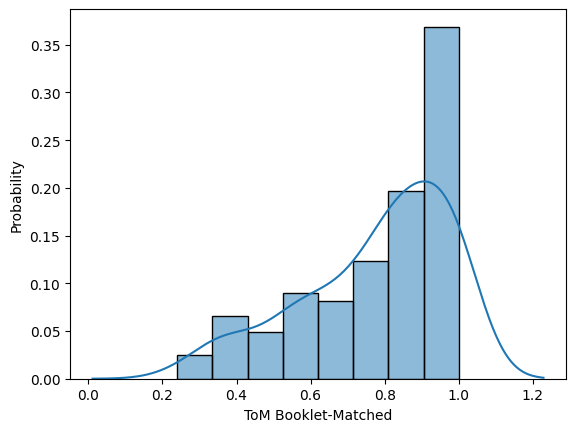

In [ ]:
# Take a look at the distribution of the ToM (target variable)
import seaborn as sns
sns.histplot(y_ToM, kde = True, stat = "probability", kde_kws = dict(cut=3))

In [ ]:
# Assign groups to subjects based on the ToM scores

# Create a function to assign subjects to different groups based on their ToM scores
def assign_group(score):
    if score >= 0.2 and score < 0.4:
        return 'Group 1'
    elif score >= 0.4 and score < 0.6:
        return 'Group 2'
    elif score >= 0.6 and score < 0.8:
        return 'Group 3'
    elif score >= 0.8 and score <= 1.0:
        return 'Group 4'
    else:
        return 'Unknown'

# Add a new column 'Group' based on the 'ToM_scores' column
df_behav["ToMGroup"] = df_behav["ToM Booklet-Matched"].apply(assign_group)

In [ ]:
df_behav

,participant_id,Age,AgeGroup,Child_Adult,Gender,Handedness,ToM Booklet-Matched,ToM Booklet-Matched-NOFB,FB_Composite,FB_Group,WPPSI BD raw,WPPSI BD scaled,KBIT_raw,KBIT_standard,DCCS Summary,Scanlog: Scanner,Scanlog: Coil,Scanlog: Voxel slize,Scanlog: Slice Gap,ToMGroup
0,sub-pixar001,4.774812,4yo,child,M,R,0.80,0.736842,6,pass,22.0,13.0,NaN,NaN,3.0,3T1,7-8yo 32ch,3mm iso,0.1,Group 4
1,sub-pixar002,4.856947,4yo,child,F,R,0.72,0.736842,4,inc,18.0,9.0,NaN,NaN,2.0,3T1,7-8yo 32ch,3mm iso,0.1,Group 3
2,sub-pixar003,4.153320,4yo,child,F,R,0.44,0.421053,3,inc,15.0,9.0,NaN,NaN,3.0,3T1,7-8yo 32ch,3mm iso,0.1,Group 2
3,sub-pixar004,4.473648,4yo,child,F,R,0.64,0.736842,2,fail,17.0,10.0,NaN,NaN,3.0,3T1,7-8yo 32ch,3mm iso,0.2,Group 3
4,sub-pixar005,4.837782,4yo,child,F,R,0.60,0.578947,4,inc,13.0,5.0,NaN,NaN,2.0,3T1,7-8yo 32ch,3mm iso,0.2,Group 3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,sub-pixar118,10.500000,8-12yo,child,F,R,1.00,1.000000,6,pass,NaN,NaN,37.0,119.0,NaN,3T1,32ch adult,3.13 mm iso,NaN,Group 4
118,sub-pixar119,8.620000,8-12yo,child,F,R,1.00,1.000000,5,pass,NaN,NaN,33.0,121.0,NaN,3T1,32ch adult,3.13 mm iso,NaN,Group 4
119,sub-pixar120,11.480000,8-12yo,child,F,R,1.00,1.000000,5,pass,NaN,NaN,38.0,117.0,NaN,3T1,32ch adult,3.13 mm iso,NaN,Group 4
120,sub-pixar121,8.760000,8-12yo,child,F,R,1.00,1.000000,6,pass,NaN,NaN,37.0,130.0,NaN,3T1,32ch adult,3.13 mm iso,NaN,Group 4


In [ ]:
ToM_class = df_behav["ToMGroup"]
ToM_class.value_counts()

,count
ToMGroup,
Group 4,72
Group 3,24
Group 2,18
Group 1,8


In [ ]:
# Fit Machine Learning to our data

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import r2_score
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import median_absolute_error
from sklearn.svm import SVR

l_svr = SVR(kernel="linear")


X_train, X_val, y_train, y_val = train_test_split(
    X_features, # x
    y_ToM, # y
    test_size = 0.3,
    shuffle = True,  # shuffle dataset before splitting
    stratify = ToM_class, # keep distribution of ToMclass consistent b/t train and test sets
    random_state = 123
)

print('training: ', len(X_train),
   'testing: ', len(X_val))

training:  85 testing:  37


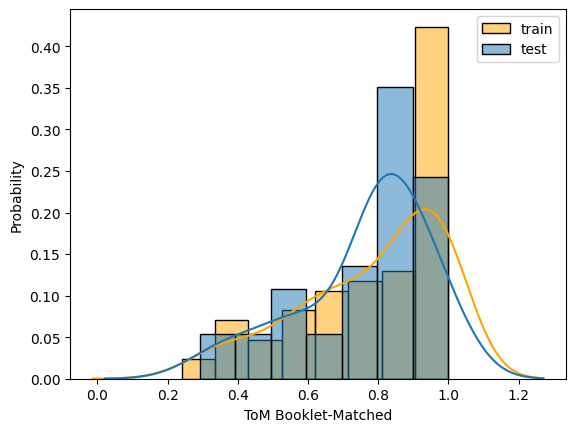

In [ ]:
# Visualized the distributions to be sure they are matched b/t train and test subset

sns.histplot(y_train, label='train', kde = True, stat = "probability", kde_kws=dict(cut=3), color = 'orange')
sns.histplot(y_val, label='test', kde=True, stat='probability', kde_kws=dict(cut=3))
plt.legend()

In [ ]:
# k-fold cross validation predict

l_svr.fit(X_train, y_train)

y_pred = cross_val_predict(l_svr, X_train, y_train, cv = 10)

acc = cross_val_score(l_svr, X_train, y_train, cv = 10)
expvar = cross_val_score(l_svr, X_train, y_train, cv = 10, scoring = 'explained_variance')
mae = cross_val_score(l_svr, X_train, y_train, cv = 10, scoring = 'neg_mean_absolute_error')
medae = cross_val_score(l_svr, X_train, y_train, cv = 10, scoring = 'neg_median_absolute_error')

# The model performance with training dataset
overall_acc = r2_score(y_train, y_pred)
overall_expvar = explained_variance_score(y_train, y_pred)
overall_mae = mean_absolute_error(y_train, y_pred)
overall_medae = median_absolute_error(y_train, y_pred)


# Create a DataFrame to store the results
results_df = pd.DataFrame({
    'R2': [overall_acc],
    'Explained Variance': [overall_expvar],
    'Mean Absolute Error': [overall_mae],
    'Median Absolute Error': [overall_medae]
})


styled_results_df = results_df.style.set_properties(**{'background-color': 'lightblue',
                                       'color': 'black',
                                       'font-family': 'Arial',
                                       'text-align': 'center'})

# Establish Model with Training Subset

In [ ]:
styled_results_df

,R2,Explained Variance,Mean Absolute Error,Median Absolute Error
0,-0.273172,-0.262598,0.195468,0.195176


In [ ]:
# Evaluate the model with validation dataset
y_val_pred = l_svr.predict(X_val) # classify ToM class using testing data
acc = l_svr.score(X_val, y_val) # get accuracy (r2)
expvar = explained_variance_score(y_val, y_val_pred) # get the explained variance
mae = mean_absolute_error(y_val, y_val_pred) # get mean absolute error
medae = median_absolute_error(y_val, y_val_pred) # get median absolute error

print('Prediction accuracy (R2): ', acc)
print('Explained variance: ', expvar)
print('Mean absolute error: ', mae)
print('Median absolute error: ', medae)

# Create a DataFrame to store the results
results_df_1 = pd.DataFrame({
    'Predictin accuracy (R2)': [acc],
    'Explained variance': [expvar],
    'Mean absolute error': [mae],
    'Median absolute error': [medae]
})

styled_results_df_1 = results_df_1.style.set_properties(**{'background-color': 'lightblue',
                                       'color': 'black',
                                       'font-family': 'Arial',
                                       'text-align': 'center'})

Prediction accuracy (R2):  -0.2666241254042412
Explained variance:  -0.1897398554058054
Mean absolute error:  0.16756643635025972
Median absolute error:  0.15255124670862158


# Validate Our Model with Unseen Data

In [ ]:
styled_results_df_1

,Predictin accuracy (R2),Explained variance,Mean absolute error,Median absolute error
0,-0.266624,-0.189740,0.167566,0.152551


In [ ]:
# plot result
sns.regplot(x=y_val_pred, y=y_val, marker = 'o')
plt.xlabel('Predicted ToM score')

In [ ]:
# Access the feature importances used by the model
l_svr.coef_

In [ ]:
print("Maximum value:", np.max(l_svr.coef_))
print("Minimum value:", np.min(l_svr.coef_))

In [ ]:
# Plot the weights to see the distribution
plt.bar(range(l_svr.coef_.shape[-1]), l_svr.coef_[0])
plt.title('feature importances')
plt.xlabel('feature')
plt.ylabel('weight')

In [ ]:
correlation_measure.inverse_transform(l_svr.coef_).shape

In [ ]:
from nilearn import plotting

feat_exp_matrix=correlation_measure.inverse_transform(l_svr.coef_)[0]

In [ ]:
plot_matrix = plotting.plot_matrix(feat_exp_matrix, figure = (10, 8),labels = range(feat_exp_matrix.shape[0]), reorder = False, tri = 'lower')

In [ ]:
# Overall connectomes
coords = plotting.find_parcellation_cut_coords(atlas_filename)

In [ ]:
plotting.plot_connectome(feat_exp_matrix, coords, colorbar = True)

In [ ]:
plotting.plot_matrix(feat_exp_matrix, figure = (10, 8),
                     labels = range(feat_exp_matrix.shape[0]),
                     reorder = False,
                     tri = 'lower',
                     vmin=0.009,
                     vmax=0.01,)

In [ ]:
# Set the threshold for the displayed nodes
plotting.plot_connectome(feat_exp_matrix, coords, colorbar = True, edge_threshold = 0.009)

In [ ]:
plotting.view_connectome(feat_exp_matrix, coords, edge_threshold=0.009,
                        edge_cmap='viridis')

In [ ]:
# Find out the corresponding coordinates
coords[[54]]

# Future Direction

* Transform the ToM score to better fit into the linear model
* Utilize bilateral atlas to capture the association between the two hemispheres and ToM ability
* Utilize other machine learning algorithms to confirm our present results
* Focus on primary ROIs to gain deeper insights into the association between functional connectivity and ToM ability

# Conclusion

* In this exploratory project, we observe the pivotal role of OFC connections in predicting ToM ability, coherent with previous research findings (Abu-Akel & Samay-Tsoory, 2011; Leopold et al., 2012).

* It is only a preliminary project. We still need to try other machine learning algorithms and more data to develop a more robust model to predict the ToM ability with functional connectivity.  


# Acknowledgement

* Gratitude to all the organizers, instructors, TAs, and fellow participants from all around the world who helped us learn all these cool open neuroscience tools and give us this opportunity to connect with all the great neuroscientists in the world.

* Special thanks to our instructor Charlene Lee, and our TA Ingrid Chuang for their inspiring work and assistance with our project.

# Reference

* Abu-Akel, A., & Shamay-Tsoory, S. (2011). Neuroanatomical and neurochemical bases of theory of mind. Neuropsychologia, 49(11), 2971-2984.

* Leopold, A., Krueger, F., dal Monte, O., Pardini, M., Pulaski, S. J., Solomon, J., & Grafman, J. (2012). Damage to the left ventromedial prefrontal cortex impacts affective theory of mind. Social Cognitive and Affective Neuroscience, 7(8), 871-880.

*  Marchetti, A., Baglio, F., Costantini, I., Dipasquale, O., Savazzi, F., Nemni, R., ... & Castelli, I. (2015). Theory of mind and the whole brain functional connectivity: Behavioral and neural evidences with the Amsterdam Resting State Questionnaire. Frontiers in psychology, 6, 1855.